In [40]:
import numpy as np
import os
import pandas as pd
import xarray as xr
from data_downloading.loader import CountryData
from models.classic_LC import LeeCarterModel
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from config import plot_configuration
from evaluation.evaluator import MortalityEvaluator

import matplotlib.patches as patches
from matplotlib import colormaps

viridis = colormaps["magma"]
colors = plt.cm.magma(np.linspace(0.95, 0.15, 30))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def train_model_pipeline(
        country_code, 
        value_column, 
        min_year, 
        max_year,
        split_year=None, 
        overlap=False,
        simulations=None, 
        verbose=False
    ):
    data = CountryData(country_code)
    data.load_data(min_year, max_year, maximum_age=90)

    if split_year:
        training, testing = data.mx.split_by_year(split_year, overlap, verbose)
        lc_model = LeeCarterModel(training, value_column=value_column).fit()
        if simulations:
            mortality_evaluation = MortalityEvaluator(lc_model, testing, simulations)
    else:
        lc_model = LeeCarterModel(data.mx, value_column=value_column).fit()

    if split_year and simulations:
        return (data, lc_model, mortality_evaluation)
    else:
        return (data, lc_model)

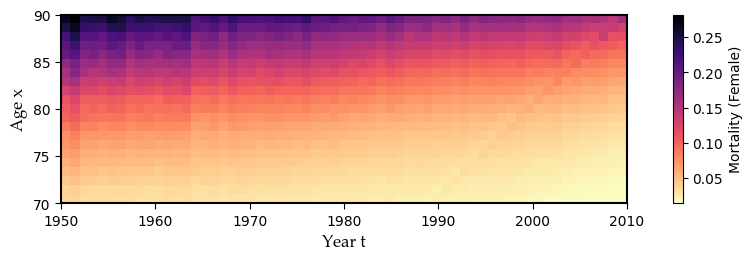

In [3]:
def create_log_heatmap(country_code, value_column, min_year, max_year, min_age, max_age):
    data, model = train_model_pipeline(country_code, value_column, min_year, max_year)
    fig, ax = plt.subplots(figsize=(7.5, 2.5), layout="constrained")
    im = ax.imshow(
        model.wide_matrix.to_pandas().query("Age >= @min_age and Age <= @max_age"),
        cmap="magma_r",
        extent=[min_year, max_year, max_age, min_age]
    )

    ax.invert_yaxis()
    cbar = fig.colorbar(im, ax=ax, label=f"Mortality ({value_column})")
    plot_configuration(ax)
    ax.set_xlabel("Year t")
    ax.set_ylabel("Age x")
    fig.savefig(f"created_plots/{country_code}_{value_column}_logheatmap.pdf", bbox_inches=None)
    plt.show()

create_log_heatmap("GBRTENW", "Female", 1950, 2010, 70, 90)

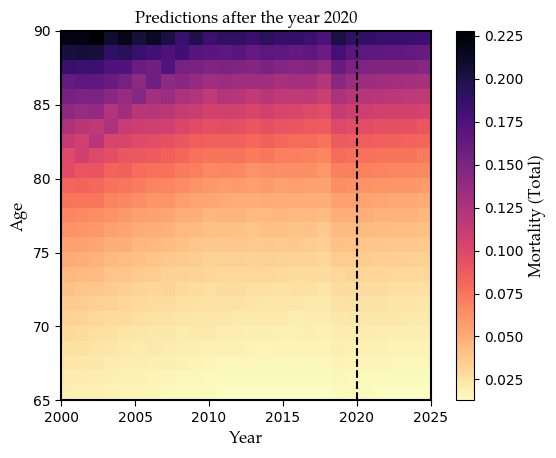

In [4]:
uk_data = CountryData(country_hmd_code="GBRTENW")
uk_data.load_data(1950, 2020, maximum_age=90)

lc_model_uk = LeeCarterModel(uk_data.mx, "Male").fit()

predictions = lc_model_uk.predict(steps=5, simulations=1)
full_matrix = pd.concat([lc_model_uk.wide_matrix.to_pandas().loc[:, 2001:], 
                         predictions.squeeze("Simulation", drop=True).to_pandas()], 
                         axis=1
)
full_matrix.head()

fig, ax = plt.subplots()
im = ax.imshow(
    full_matrix.query("Age > 65"),
    cmap="magma_r",
    extent=[2000, 2025, 90, 65]
)

ax.invert_yaxis()
ax.axvline(x=2020, linestyle="dashed", linewidth=1.5, color="black")
cbar = fig.colorbar(im, ax=ax, label="Mortality (Total)")
plot_configuration(ax, colorbar_object=cbar)
ax.set_xlabel("Year")
ax.set_ylabel("Age")
ax.set_title("Predictions after the year 2020")

plt.show()

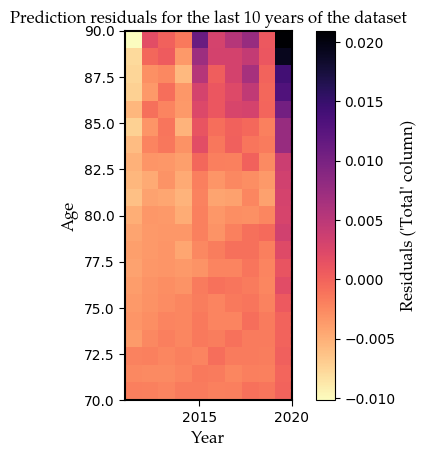

In [6]:
split_year = 2010
max_year = 2020
_, _, mortality_evaluation = train_model_pipeline("GBRTENW", "Female", 1950, max_year, split_year, simulations=1000)
residuals = mortality_evaluation.calculate_residuals("mean")

fig, ax = plt.subplots()
im = ax.imshow(
    residuals.to_pandas().query("Age >= 70"),
    cmap="magma_r",
    extent=[split_year + 1, max_year, 90, 70]
    )

ax.invert_yaxis()
ax.axvline(x=max_year, linestyle="dashed", linewidth=1.5, color="black")
cbar = fig.colorbar(im, ax=ax, label="Residuals ('Total' column)")
plot_configuration(ax, colorbar_object=cbar)
ax.set_xlabel("Year")
ax.set_ylabel("Age")
ax.set_title("Prediction residuals for the last 10 years of the dataset")

plt.show()